In [1]:
import shlex
import subprocess
from pathlib import Path
from typing import Callable
from dotenv import load_dotenv
from skills_ref import to_prompt
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.messages import SystemMessage
from langchain_core.messages import HumanMessage
from langchain_community.tools import ShellTool
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse

load_dotenv()

True

In [2]:
@tool
def get_skill_instruction(skill_name: str) -> str:
    """获取指定技能的详细指令及脚本清单。"""
    base = Path("./skills") / skill_name
    file = base / "SKILL.md"

    if not file.exists():
        return f"错误：找不到技能 {skill_name}"

    content = file.read_text(encoding="utf-8")
    body = content.split("---")[-1].strip()

    scripts = [f.name for f in (base / "scripts").glob("*") if f.is_file()]
    script_info = f"\n\n📂 **可用脚本**: {', '.join(scripts)}" if scripts else "\n\n📂 **可用脚本**: 无"

    return (
        f"# {skill_name} 详情\n"
        f"📍 **技能路径**: `{base}`\n\n"
        f"{body}"
        f"{script_info}"
    )


@wrap_model_call
def add_context(
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    skills_root = Path("./skills")
    skill_paths = [p for p in skills_root.iterdir() if p.is_dir() and (p / "SKILL.md").exists()]
    skills_catalog = to_prompt(skill_paths)
    system_prompt = f"""
# Role
你是一个功能强大的通用人工智能助手。为了更高效、精准地完成复杂任务，你拥有访问“专用技能库”的权限。

# 技能目录 (Skill Catalog)
以下是你当前可以调用的扩展技能列表。每个技能包含名称和核心功能简述：

{skills_catalog}

# 核心操作逻辑 (Operating Logic)
当你处理用户请求时，请遵循以下决策流程：

1. **意图匹配**：判断用户需求是否落在上述 [技能目录] 的覆盖范围内。
2. **按需检索**：如果你决定使用某个技能，**严禁凭经验盲目猜测其操作细节**。你必须立即调用工具 `get_skill_instruction(skill_name)` 来获取该技能的“详细操作手册”。
3. **知识利用**：
    - 阅读手册中提供的执行步骤、参数规范及约束条件。
    - 如果手册中提到需要运行特定的脚本（通常位于 `skills/技能名/scripts/`），请严格按照说明执行对应的命令行操作。
4. **组合执行**：你可以根据任务复杂度，依次检索并利用多个技能来构建完整的解决方案。

# 行为约束
- **先读后做**：在未获取详细指令前，不得尝试调用该技能目录下的任何脚本或文件。
- **路径感知**：使用相对于当前工作目录的完整路径。
- **Shell 转义安全 (重要)**：
    - 当使用 `run_shell_command` 执行包含复杂参数（如 JSON）的命令时，**必须**使用单引号 `'` 包裹整个 JSON 字符串。
    - 在单引号包裹的 JSON 内部，**必须**使用双引号 `"` 来界定键和值。
    - 示例正确格式：`--scripts '{{"main.py": "print(1)"}}'`
- **结果导向**：利用技能解决问题后，简洁反馈结果。
"""
    system_message = SystemMessage(content=system_prompt)
    return handler(request.override(system_message=system_message))

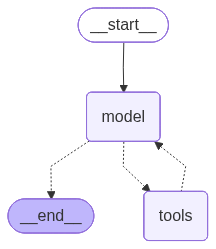

In [3]:
agent = create_agent(ChatOpenAI(model="qwen-plus"), tools=[get_skill_instruction, ShellTool()],
                     middleware=[add_context])
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [6]:
user_query = "现在几点了"

inputs = {"messages": [HumanMessage(content=user_query)]}

for output in agent.stream(inputs, config={"recursion_limit": 10}, stream_mode="values"):
    output["messages"][-1].pretty_print()

================================ Human Message =================================

现在几点了
================================== Ai Message ==================================

我无法获取当前系统时间，因为我没有访问系统时钟或实时日期时间的权限。如果你需要知道当前时间，建议查看你设备右下角（Windows）或右上角（macOS）的系统托盘时间显示。

如有其他任务（例如构建新技能、执行脚本等），我很乐意协助！


In [8]:
user_query = "帮我创建一个可以获取时间的技能。"

inputs = {"messages": [HumanMessage(content=user_query)]}

for output in agent.stream(inputs, config={"recursion_limit": 20}, stream_mode="values"):
    output["messages"][-1].pretty_print()

================================ Human Message =================================

帮我创建一个可以获取时间的技能。
================================== Ai Message ==================================

你希望创建一个“获取时间”的技能。这是一个典型的轻量级工具型技能，适合用 `skill-builder` 来封装。

首先，我需要获取 `skill-builder` 的详细操作手册，以确保严格遵循其规范（如目录结构、SKILL.md 格式、脚本要求等）来构建新技能。
Tool Calls:
  get_skill_instruction (call_9f85f4823da7451ebff647)
 Call ID: call_9f85f4823da7451ebff647
  Args:
    skill_name: skill-builder
================================= Tool Message =================================
Name: get_skill_instruction

# skill-builder 详情
📍 **技能路径**: `skills/skill-builder`

```

**目录结构示例：**

```bash
mkdir -p chinese-to-english-translator/{scripts,references}
touch chinese-to-english-translator/SKILL.md

```

## 常见错误提醒
* **生成的前缀不满足格式要求。**。
* **生成的目录结构有误，需要放在skills文件夹下。**
* **不要**在 `name` 中使用大写字母。
* **不要**在 `SKILL.md` 中放入海量原始数据，应使用 `assets/` 或 `references/`。
* **确保**所有 `scripts/` 下的脚本都具备良好的错误处理机制。

📂 **可用脚本**: 无
==================================

/Users/zhengjie/Documents/learn-langchain/.venv/lib/python3.11/site-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


================================== Ai Message ==================================

目录结构已创建成功 ✅  
接下来，我将生成符合规范的 `skills/get-time/SKILL.md` 文件。

根据 Agent Skills 规范，`SKILL.md` 至少需包含以下字段：
- `name`: 技能名（小写、短横线分隔）→ `get-time`
- `description`: 一句话功能描述
- `input_schema`: JSON Schema，此处无输入参数 → 空对象 `{}` 或明确 `"type": "object", "properties": {}`
- `output_schema`: 描述返回值，如 `{"type": "string", "format": "date-time"}`
- `scripts`: 列出脚本文件名（如 `["main.py"]`）
- （可选但推荐）`examples` 和 `constraints`

同时，编写 `skills/get-time/scripts/main.py`，要求：
- 输出 ISO 格式时间（如 `"2024-05-22T14:36:22.123456+08:00"`）；
- 具备基础异常处理；
- 使用 `print()` 直接输出（Agent 将捕获 stdout）。

现在生成 `SKILL.md` 和 `main.py`：
Tool Calls:
  terminal (call_e57a1e15e3c1462f8b4879)
 Call ID: call_e57a1e15e3c1462f8b4879
  Args:
    commands: ['cat > skills/get-time/SKILL.md << \'EOF\'\n# get-time\n\n## Description\nReturns the current system time in ISO 8601 format with timezone.\n\n## Input Schema\n```json\n{}\n```\n\n## Output Schema\n```json\n{\n  "type": "strin

/Users/zhengjie/Documents/learn-langchain/.venv/lib/python3.11/site-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


ParseError: SKILL.md must start with YAML frontmatter (---)

In [ ]:
user_query = "现在几点了"

inputs = {"messages": [HumanMessage(content=user_query)]}

for output in agent.stream(inputs, config={"recursion_limit": 10}, stream_mode="values"):
    output["messages"][-1].pretty_print()